# 🏠 Saudi Arabia Real Estate Analysis

## 📋 Project Overview
This project analyzes **1,480 real estate properties** across 4 major Saudi cities (Riyadh, Jeddah, Dammam, Khobar) to uncover pricing patterns and market insights.

## 🎯 Objectives
- Identify the most expensive cities and districts
- Analyze factors affecting property prices
- Discover the impact of amenities (pool, garage, etc.) on pricing
- Provide actionable insights for buyers and investors

## 📊 Dataset
- **Source:** Kaggle (Saudi Arabia Real Estate - AQAR)
- **Size:** 1,480 properties (after cleaning)
- **Features:** 24 columns including price, size, location, and amenities

## 🛠️ Tools Used
- Python (Pandas, NumPy)
- Matplotlib & Seaborn for visualization

## 1️⃣ Loading the Data
We start by importing the dataset and taking a first look at its structure.

In [57]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("data/SA_Aqar.csv")
df.head()

,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,...,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price,details
0,الرياض,حي العارض,شمال,250,0,5,5,1,1,1,...,0,0,1,0,1,1,0,0,80000,للايجار فيلا دبلكس في موقع ممتاز جدا بالقرب من...
1,الرياض,حي القادسية,جنوب,370,0,4,5,2,1,1,...,0,0,1,0,0,1,0,0,60000,*** فيلا درج مع الصالة جديدة ***\n\nعبارة عن م...
2,الرياض,حي القادسية,جنوب,380,0,4,5,1,1,1,...,1,0,1,0,0,1,0,0,60000,فيلا للايجار درج داخلي مشب خارجي مجلس مقلط وصا...
3,الرياض,حي المعيزلة,غرب,250,0,5,5,3,0,1,...,0,0,1,0,0,0,0,0,55000,فيلا للايجار جديده لن تستخدم ش...
4,الرياض,حي العليا,غرب,400,11,7,5,2,1,1,...,1,0,1,0,1,1,0,0,70000,فيلا للايجار حي العليا \n\nالارضي مجالس وغرفتي...


## 2️⃣ Data Exploration
Here we examine the dataset's size, columns, and identify any data quality issues.

In [58]:
df.shape[0]

3718

In [59]:
df.shape[1]

24

In [60]:
df.columns.tolist()

['city',
 'district',
 'front',
 'size',
 'property_age',
 'bedrooms',
 'bathrooms',
 'livingrooms',
 'kitchen',
 'garage',
 'driver_room',
 'maid_room',
 'furnished',
 'ac',
 'roof',
 'pool',
 'frontyard',
 'basement',
 'duplex',
 'stairs',
 'elevator',
 'fireplace',
 'price',
 'details']

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3718 entries, 0 to 3717
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   city          3718 non-null   str  
 1   district      3718 non-null   str  
 2   front         3718 non-null   str  
 3   size          3718 non-null   int64
 4   property_age  3718 non-null   int64
 5   bedrooms      3718 non-null   int64
 6   bathrooms     3718 non-null   int64
 7   livingrooms   3718 non-null   int64
 8   kitchen       3718 non-null   int64
 9   garage        3718 non-null   int64
 10  driver_room   3718 non-null   int64
 11  maid_room     3718 non-null   int64
 12  furnished     3718 non-null   int64
 13  ac            3718 non-null   int64
 14  roof          3718 non-null   int64
 15  pool          3718 non-null   int64
 16  frontyard     3718 non-null   int64
 17  basement      3718 non-null   int64
 18  duplex        3718 non-null   int64
 19  stairs        3718 non-null   int64
 2

In [62]:
df.describe()

,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,driver_room,maid_room,furnished,ac,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price
count,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3.718000e+03
mean,390.968531,5.064820,5.083916,4.606509,2.243948,0.909360,0.802044,0.495697,0.795320,0.123453,0.560785,0.521517,0.162453,0.802582,0.034158,0.499462,0.814416,0.080958,0.181280,8.738797e+04
std,1565.056135,7.590427,1.230040,0.703449,0.916436,0.287135,0.398512,0.500049,0.403522,0.329001,0.496358,0.499604,0.368915,0.398104,0.181660,0.500067,0.388823,0.272807,0.385302,7.063470e+04
min,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+03
25%,280.000000,0.000000,4.000000,4.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,5.500000e+04
50%,330.000000,2.000000,5.000000,5.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,7.000000e+04
75%,400.000000,7.000000,6.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000e+05
max,95000.000000,36.000000,7.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.700000e+06


In [63]:
df.isna().sum()

city             0
district         0
front            0
size             0
property_age     0
bedrooms         0
bathrooms        0
livingrooms      0
kitchen          0
garage           0
driver_room      0
maid_room        0
furnished        0
ac               0
roof             0
pool             0
frontyard        0
basement         0
duplex           0
stairs           0
elevator         0
fireplace        0
price            0
details         80
dtype: int64

In [64]:
df.duplicated().sum()

np.int64(2197)

In [65]:
df["city"].unique()

<StringArray>
[' الرياض', ' جدة', ' الدمام', ' الخبر']
Length: 4, dtype: str

In [66]:
df["city"].value_counts()

city
الخبر     976
الرياض    960
الدمام    894
جدة       888
Name: count, dtype: int64

In [67]:
df["price"].describe()

count    3.718000e+03
mean     8.738797e+04
std      7.063470e+04
min      1.000000e+03
25%      5.500000e+04
50%      7.000000e+04
75%      1.000000e+05
max      1.700000e+06
Name: price, dtype: float64

In [68]:
df["price"].max()

np.int64(1700000)

In [69]:
df["price"].min()

np.int64(1000)

In [70]:
df["price"].mean()

np.float64(87387.97417966649)

In [71]:
df["district"].value_counts().head(10)

district
حي ضاحية الملك فهد     173
حي اللؤلؤ              149
حي الصواري             149
حي التحلية             149
حي العارض              137
حي طيبة                124
حي الرمال              119
حي الروضة              116
حي المحمدية            104
حي المنار              100
Name: count, dtype: int64

In [72]:
features = ["pool", "garage","elevator","fireplace","basement","duplex","furnished"]

for feature in features:
    count = df[feature].sum()
    percent = (count / len(df)) * 100
    print(f"{feature}: {count} عقار ({percent:.1f}%)")

pool: 604 عقار (16.2%)
garage: 2982 عقار (80.2%)
elevator: 301 عقار (8.1%)
fireplace: 674 عقار (18.1%)
basement: 127 عقار (3.4%)
duplex: 1857 عقار (49.9%)
furnished: 459 عقار (12.3%)


## 3️⃣ Data Cleaning
The raw data had several issues that we addressed:
- **2,197 duplicate rows** removed
- **Whitespace** in text columns standardized
- **Outliers** in size and price filtered out

**Result:** Clean dataset reduced from 3,718 to 1,480 rows.

In [73]:
df_clean = df.copy()

In [74]:
df_clean

,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,...,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price,details
0,الرياض,حي العارض,شمال,250,0,5,5,1,1,1,...,0,0,1,0,1,1,0,0,80000,للايجار فيلا دبلكس في موقع ممتاز جدا بالقرب من...
1,الرياض,حي القادسية,جنوب,370,0,4,5,2,1,1,...,0,0,1,0,0,1,0,0,60000,*** فيلا درج مع الصالة جديدة ***\n\nعبارة عن م...
2,الرياض,حي القادسية,جنوب,380,0,4,5,1,1,1,...,1,0,1,0,0,1,0,0,60000,فيلا للايجار درج داخلي مشب خارجي مجلس مقلط وصا...
3,الرياض,حي المعيزلة,غرب,250,0,5,5,3,0,1,...,0,0,1,0,0,0,0,0,55000,فيلا للايجار جديده لن تستخدم ش...
4,الرياض,حي العليا,غرب,400,11,7,5,2,1,1,...,1,0,1,0,1,1,0,0,70000,فيلا للايجار حي العليا \n\nالارضي مجالس وغرفتي...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3713,الخبر,حي اللؤلؤ,غرب,437,0,7,5,2,1,1,...,1,0,1,0,1,1,0,1,60000,للإيجار فيلا دورين وملحق في حي الأصداف\n\nالمس...
3714,الخبر,حي الصواري,جنوب,400,0,5,5,3,0,1,...,1,0,1,0,1,1,0,0,55000,دبلكس للأيجار حي الصواري ج ٤٣\n\nمجلس خارجي (د...
3715,الخبر,حي اللؤلؤ,غرب,330,0,6,4,2,1,0,...,1,0,1,0,1,0,0,1,37000,حوش مجلس خارجي مجلس رجال دورة مياة مجلط صاله ...
3716,الخبر,حي الكورنيش,جنوب,300,13,6,5,2,1,1,...,0,0,1,0,1,1,0,0,90000,فيلا فاخرة في حي كورنيش الخبر. أفضل حي بالخبر....


In [75]:
print(f"عدد المكرررات :{df_clean.duplicated().sum()}")

عدد المكرررات :2197


In [76]:
df_clean = df_clean.drop_duplicates()
print(f"الصفوف بعد ازالة المكررات: {len(df_clean)}")

الصفوف بعد ازالة المكررات: 1521


In [77]:

print("قبل التنظيف")
print(df_clean["city"].unique())

df_clean["city"] = df_clean["city"].str.strip()

print("\n بعد التنظيف")
print(df_clean["city"].unique())

قبل التنظيف
<StringArray>
[' الرياض', ' جدة', ' الدمام', ' الخبر']
Length: 4, dtype: str

 بعد التنظيف
<StringArray>
['الرياض', 'جدة', 'الدمام', 'الخبر']
Length: 4, dtype: str


In [78]:
df_clean["district"] = df_clean["district"].str.strip()
print(f"عدد الاحياء :{df_clean["district"].nunique()}")

عدد الاحياء :174


In [79]:
print("قبل:", df_clean["front"].unique())
df_clean["front"] = df_clean["front"].str.strip()
print("بعد:", df_clean["front"].unique())

قبل: <StringArray>
[     'شمال',      'جنوب',       'غرب',       'شرق', 'جنوب شرقي', 'جنوب غربي',
 'شمال غربي', 'شمال شرقي',   '3 شوارع',   '4 شوارع']
Length: 10, dtype: str
بعد: <StringArray>
[     'شمال',      'جنوب',       'غرب',       'شرق', 'جنوب شرقي', 'جنوب غربي',
 'شمال غربي', 'شمال شرقي',   '3 شوارع',   '4 شوارع']
Length: 10, dtype: str


## 4️⃣ Data Analysis
We analyze pricing patterns across cities, districts, and property features.

In [80]:
print("إحصائيات size:")
print(df_clean["size"].describe())

print("\nأقل 5 مساحات:")
print(df_clean["size"].nsmallest(5))

print("\nأكبر 5 مساحات:")
print(df_clean["size"].nlargest(5))

إحصائيات size:
count     1521.000000
mean       464.804734
std       2441.819679
min          1.000000
25%        300.000000
50%        350.000000
75%        420.000000
max      95000.000000
Name: size, dtype: float64

أقل 5 مساحات:
1126      1
961     100
974     110
2786    111
615     120
Name: size, dtype: int64

أكبر 5 مساحات:
997     95000
1323     5000
209      3060
99       3000
535      2944
Name: size, dtype: int64


In [81]:
# نشوف عدد العقارات اللي ضمن النطاق المنطقي
mask = (df_clean["size"] >= 50) & (df_clean["size"] <= 5000)
print(f"عقارات ضمن النطاق المنطقي (50-5000): {mask.sum()}")
print(f"عقارات خارج النطاق: {(~mask).sum()}")

# نحذف القيم الشاذة
df_clean = df_clean[mask]
print(f"\nالصفوف بعد إزالة قيم size الشاذة: {len(df_clean)}")

عقارات ضمن النطاق المنطقي (50-5000): 1519
عقارات خارج النطاق: 2

الصفوف بعد إزالة قيم size الشاذة: 1519


In [82]:
print("إحصائيات السعر:")
print(df_clean["price"].describe())

# نشوف توزيع السعر
print("\nأقل 5 أسعار:")
print(df_clean["price"].nsmallest(5))

print("\nأكبر 5 أسعار:")
print(df_clean["price"].nlargest(5))

إحصائيات السعر:
count    1.519000e+03
mean     9.947629e+04
std      9.638603e+04
min      1.000000e+03
25%      5.120000e+04
50%      8.000000e+04
75%      1.200000e+05
max      1.700000e+06
Name: price, dtype: float64

أقل 5 أسعار:
1170    1000
1971    1000
1157    1100
1202    1500
858     2000
Name: price, dtype: int64

أكبر 5 أسعار:
1206    1700000
1168    1300000
168      800000
417      800000
950      800000
Name: price, dtype: int64


In [83]:
# نطاق منطقي للإيجار السنوي
price_mask = (df_clean["price"] >= 15000) & (df_clean["price"] <= 500000)
print(f"عقارات ضمن النطاق (15K-500K): {price_mask.sum()}")
print(f"عقارات خارج النطاق: {(~price_mask).sum()}")

df_clean = df_clean[price_mask]
print(f"\nالصفوف بعد إزالة الأسعار الشاذة: {len(df_clean)}")

عقارات ضمن النطاق (15K-500K): 1480
عقارات خارج النطاق: 39

الصفوف بعد إزالة الأسعار الشاذة: 1480


In [84]:
print(f"قيم فاضية في details: {df_clean['details'].isna().sum()}")

# نملأها بـ "No details"
df_clean["details"] = df_clean["details"].fillna("No details")

print(f"بعد الملء: {df_clean['details'].isna().sum()}")

قيم فاضية في details: 50
بعد الملء: 0


In [85]:
print("=" * 50)
print("📊 تقرير التنظيف النهائي")
print("=" * 50)

print(f"\n✅ الصفوف الأصلية:      {len(df):,}")
print(f"✅ الصفوف بعد التنظيف:   {len(df_clean):,}")
print(f"✅ تم حذف:                {len(df) - len(df_clean):,} صف")

print(f"\n📋 القيم الفاضية:")
print(df_clean.isna().sum())

print(f"\n🔄 المكررات: {df_clean.duplicated().sum()}")

print(f"\n🏙️ المدن: {df_clean['city'].unique()}")
print(f"📍 عدد الأحياء: {df_clean['district'].nunique()}")

print(f"\n💰 نطاق السعر: {df_clean['price'].min():,} - {df_clean['price'].max():,}")
print(f"📐 نطاق المساحة: {df_clean['size'].min()} - {df_clean['size'].max()}")

📊 تقرير التنظيف النهائي

✅ الصفوف الأصلية:      3,718
✅ الصفوف بعد التنظيف:   1,480
✅ تم حذف:                2,238 صف

📋 القيم الفاضية:
city            0
district        0
front           0
size            0
property_age    0
bedrooms        0
bathrooms       0
livingrooms     0
kitchen         0
garage          0
driver_room     0
maid_room       0
furnished       0
ac              0
roof            0
pool            0
frontyard       0
basement        0
duplex          0
stairs          0
elevator        0
fireplace       0
price           0
details         0
dtype: int64

🔄 المكررات: 0

🏙️ المدن: <StringArray>
['الرياض', 'جدة', 'الدمام', 'الخبر']
Length: 4, dtype: str
📍 عدد الأحياء: 174

💰 نطاق السعر: 15,000 - 450,000
📐 نطاق المساحة: 100 - 3060


In [86]:
df_clean.to_csv("data/SA_Aqar_clean.csv", index=False)
print("✅ تم حفظ الملف النظيف!")

✅ تم حفظ الملف النظيف!


In [87]:
# متوسط السعر لكل مدينة
df_clean.groupby("city")["price"].mean()

city
الخبر      75613.855422
الدمام     61647.058824
الرياض     91677.941176
جدة       113777.931472
Name: price, dtype: float64

In [88]:
city_report = df_clean.groupby("city").agg({
    "price": "mean",
    "size": "mean",
    "bedrooms": "mean",
    "city": "count"   # ← عدد العقارات
}).round(2)

city_report.columns = ["متوسط السعر", "متوسط المساحة", "متوسط الغرف", "عدد العقارات"]
city_report

,متوسط السعر,متوسط المساحة,متوسط الغرف,عدد العقارات
city,,,,
الخبر,75613.86,393.96,4.88,83
الدمام,61647.06,345.33,5.34,119
الرياض,91677.94,388.47,4.84,884
جدة,113777.93,427.15,5.04,394


In [89]:
df_clean.groupby("city")["price"].mean().sort_values(ascending=False)

city
جدة       113777.931472
الرياض     91677.941176
الخبر      75613.855422
الدمام     61647.058824
Name: price, dtype: float64

In [90]:
expensive_city = df_clean.groupby("city")["price"].mean().idxmax()
cheap_city = df_clean.groupby("city")["price"].mean().idxmin()

print(f"🏆 أغلى مدينة: {expensive_city}")
print(f"💰 أرخص مدينة: {cheap_city}")

🏆 أغلى مدينة: جدة
💰 أرخص مدينة: الدمام


In [91]:
# حساب سعر المتر المربع لكل مدينة
df_clean["price_per_sqm"] = df_clean["price"] / df_clean["size"]

# متوسط سعر المتر لكل مدينة
sqm_price = df_clean.groupby("city")["price_per_sqm"].mean().sort_values(ascending=False).round(2)
print("💎 متوسط سعر المتر المربع (ريال/م²):")
print(sqm_price)

💎 متوسط سعر المتر المربع (ريال/م²):
city
جدة       293.53
الرياض    257.84
الخبر     220.18
الدمام    183.55
Name: price_per_sqm, dtype: float64


In [92]:
top_districts = df_clean.groupby("district")["price"].mean().sort_values(ascending=False).head(10).round(2)
print("🏆 أغلى 10 أحياء في السعودية:")
print(top_districts)

🏆 أغلى 10 أحياء في السعودية:
district
حي حطين                256666.67
حي الاصالة             250000.00
حي جرير                235000.00
حي الوادي              214000.00
حي السفارات            212000.00
حي النموذجية           210000.00
حي المؤتمرات           187500.00
حي الشاطئ              179102.56
حي الخالدية            169285.71
حي ام الحمام الغربي    168600.00
Name: price, dtype: float64


In [93]:
cheap_districts = df_clean.groupby("district")["price"].mean().sort_values(ascending=True).head(10).round(2)
print("💰 أرخص 10 أحياء في السعودية:")
print(cheap_districts)

💰 أرخص 10 أحياء في السعودية:
district
حي الحائر            16000.00
حي منفوحة الجديدة    20000.00
حي الشفا             25000.00
حي السفن             30000.00
حي الفرسان           30000.00
حي الاسكان           30000.00
حي النسيم الشرقي     33000.00
حي الأمل             35000.00
حي ام حبلين          35000.00
حي الجنادرية         35566.67
Name: price, dtype: float64


In [94]:
# تجميع البيانات (مدينة + حي)
city_district = df_clean.groupby(["city", "district"])["price"].mean().reset_index()

# لكل مدينة، أعلى حي
print("🏆 أغلى حي في كل مدينة:")
for city in df_clean["city"].unique():
    city_data = city_district[city_district["city"] == city]
    top = city_data.loc[city_data["price"].idxmax()]
    print(f"\n{city}:")
    print(f"  الحي: {top['district']}")
    print(f"  السعر: {top['price']:,.2f} ريال")

🏆 أغلى حي في كل مدينة:

الرياض:
  الحي: حي حطين
  السعر: 256,666.67 ريال

جدة:
  الحي: حي الواحة
  السعر: 290,000.00 ريال

الدمام:
  الحي: حي المنتزه
  السعر: 140,000.00 ريال

الخبر:
  الحي: حي الاندلس
  السعر: 160,000.00 ريال


In [95]:
# correlation = الارتباط بين متغيرين
correlation = df_clean["size"].corr(df_clean["price"])
print(f"الارتباط بين المساحة والسعر: {correlation:.3f}")

الارتباط بين المساحة والسعر: 0.418


In [96]:
# نختار الأعمدة الرقمية المهمة
numeric_cols = ["size", "property_age", "bedrooms", "bathrooms", "livingrooms", "price"]
correlation_matrix = df_clean[numeric_cols].corr().round(2)
correlation_matrix

,size,property_age,bedrooms,bathrooms,livingrooms,price
size,1.00,0.36,0.17,0.09,0.22,0.42
property_age,0.36,1.00,0.16,-0.02,0.13,0.13
bedrooms,0.17,0.16,1.00,0.27,0.17,0.01
bathrooms,0.09,-0.02,0.27,1.00,0.25,0.10
livingrooms,0.22,0.13,0.17,0.25,1.00,0.32
price,0.42,0.13,0.01,0.10,0.32,1.00


In [97]:
# تجميع العقارات بـ groups من العمر
df_clean["age_group"] = pd.cut(df_clean["property_age"], 
                                bins=[-1, 2, 5, 10, 50],
                                labels=["جديد (0-2)", "حديث (3-5)", "متوسط (6-10)", "قديم (11+)"])

age_analysis = df_clean.groupby("age_group")["price"].mean().round(2)
print("متوسط السعر حسب عمر العقار:")
print(age_analysis)

متوسط السعر حسب عمر العقار:
age_group
جديد (0-2)       81153.99
حديث (3-5)       97245.00
متوسط (6-10)    111501.91
قديم (11+)      106558.22
Name: price, dtype: float64


In [98]:
print("متوسط السعر مع/بدون مسبح:")
print(df_clean.groupby("pool")["price"].mean().round(2))

# الفرق
with_pool = df_clean[df_clean["pool"] == 1]["price"].mean()
without_pool = df_clean[df_clean["pool"] == 0]["price"].mean()
diff = ((with_pool - without_pool) / without_pool) * 100
print(f"\nالعقار بمسبح يزيد السعر بـ: {diff:.1f}%")

متوسط السعر مع/بدون مسبح:
pool
0     85257.95
1    137627.97
Name: price, dtype: float64

العقار بمسبح يزيد السعر بـ: 61.4%


In [99]:
print("متوسط السعر مع/بدون كراج:")
print(df_clean.groupby("garage")["price"].mean().round(2))

with_garage = df_clean[df_clean["garage"] == 1]["price"].mean()
without_garage = df_clean[df_clean["garage"] == 0]["price"].mean()
diff = ((with_garage - without_garage) / without_garage) * 100
print(f"\nالعقار بكراج يزيد السعر بـ: {diff:.1f}%")

متوسط السعر مع/بدون كراج:
garage
0    82363.64
1    96320.44
Name: price, dtype: float64

العقار بكراج يزيد السعر بـ: 16.9%


In [100]:
features = ["pool", "garage", "elevator", "fireplace", "basement", "duplex", "furnished"]

print("📊 أثر المرافق على السعر:")
print("=" * 50)

results = []
for feature in features:
    with_f = df_clean[df_clean[feature] == 1]["price"].mean()
    without_f = df_clean[df_clean[feature] == 0]["price"].mean()
    diff_pct = ((with_f - without_f) / without_f) * 100
    
    results.append({
        "المرفق": feature,
        "بدون": round(without_f),
        "مع": round(with_f),
        "الفرق %": round(diff_pct, 1)
    })

results_df = pd.DataFrame(results).sort_values("الفرق %", ascending=False)
results_df

📊 أثر المرافق على السعر:


,المرفق,بدون,مع,الفرق %
4,basement,89765,160319,78.6
0,pool,85258,137628,61.4
2,elevator,90775,133223,46.8
6,furnished,90038,124442,38.2
1,garage,82364,96320,16.9
3,fireplace,96040,85906,-10.6
5,duplex,99133,86194,-13.1


In [101]:
# حفظ النسخة المحدثة مع الأعمدة الجديدة (price_per_sqm, age_group)
df_clean.to_csv("data/SA_Aqar_final.csv", index=False)
print("✅ تم حفظ النسخة النهائية!")

✅ تم حفظ النسخة النهائية!


## 5️⃣ Data Visualization
Visual representation of our key findings.

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)

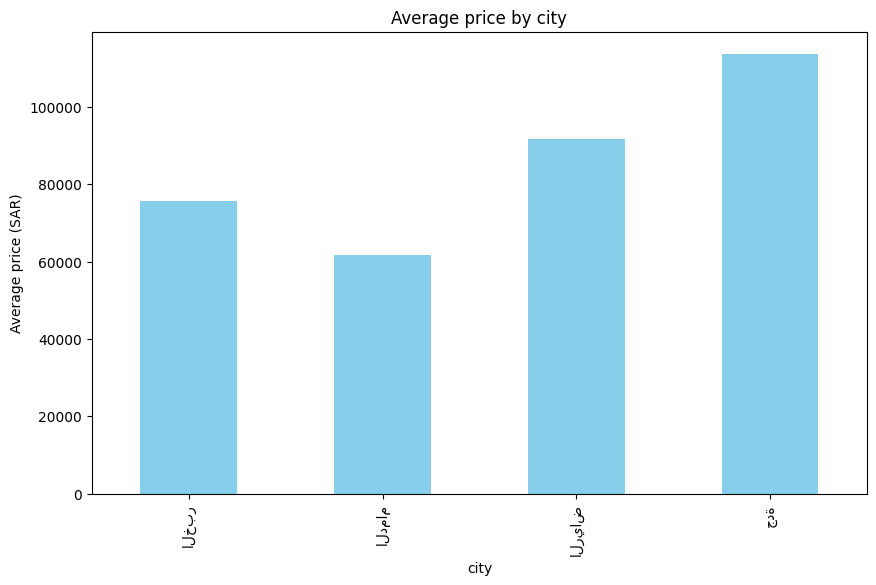

In [103]:
data = df_clean.groupby("city")["price"].mean()
data.plot(kind="bar",color="skyblue")
plt.title("Average price by city")
plt.xlabel("city")
plt.ylabel("Average price (SAR)")
plt.show()

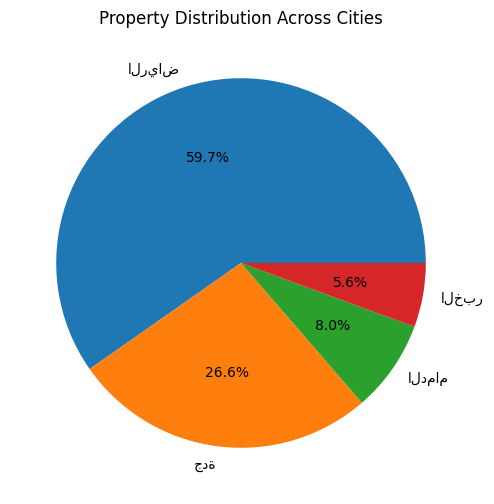

In [104]:
# للـ Pie، نستخدم value_counts (عد كل فئة)
data = df_clean["city"].value_counts()

data.plot(kind="pie", autopct="%1.1f%%")
plt.title("Property Distribution Across Cities")
plt.ylabel("")    
plt.show()

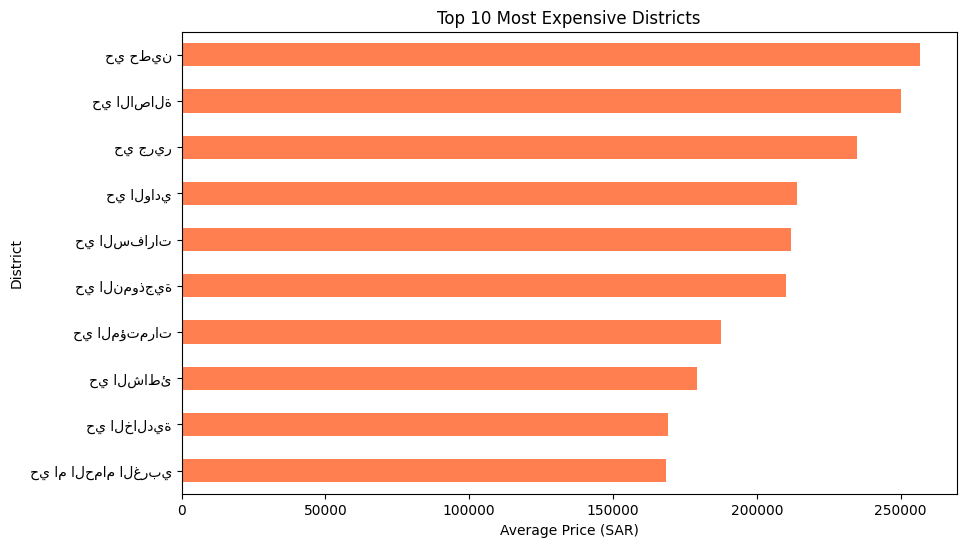

In [105]:
data = df_clean.groupby("district")["price"].mean().sort_values(ascending=False).head(10)

data.plot(kind="barh", color="coral")
plt.title("Top 10 Most Expensive Districts")
plt.xlabel("Average Price (SAR)")
plt.ylabel("District")
plt.gca().invert_yaxis()
plt.show()

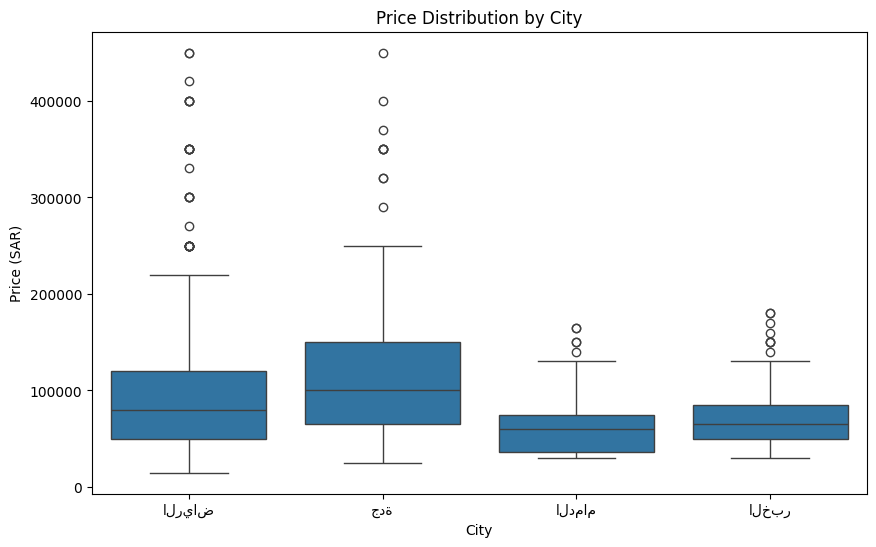

In [106]:
sns.boxplot(data=df_clean, x="city", y="price")
plt.title("Price Distribution by City")
plt.xlabel("City")
plt.ylabel("Price (SAR)")
plt.show()

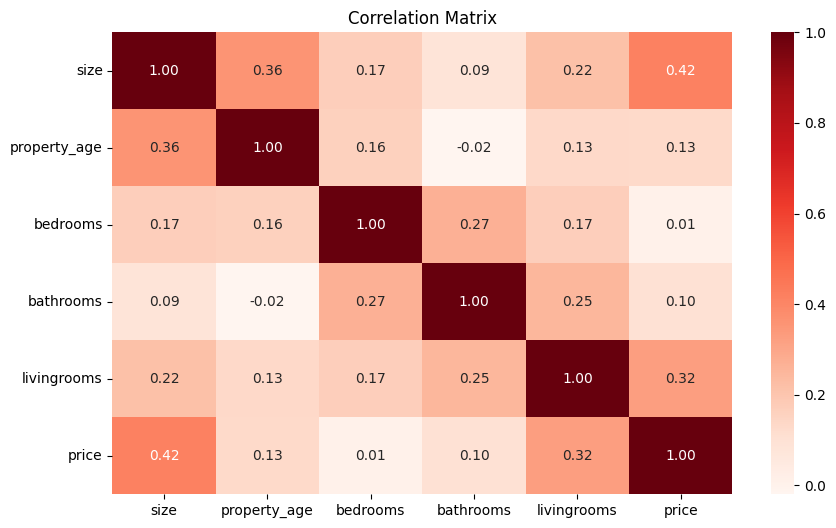

In [107]:
numeric_cols = ["size", "property_age", "bedrooms", "bathrooms", "livingrooms", "price"]

corr = df_clean[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="Reds", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

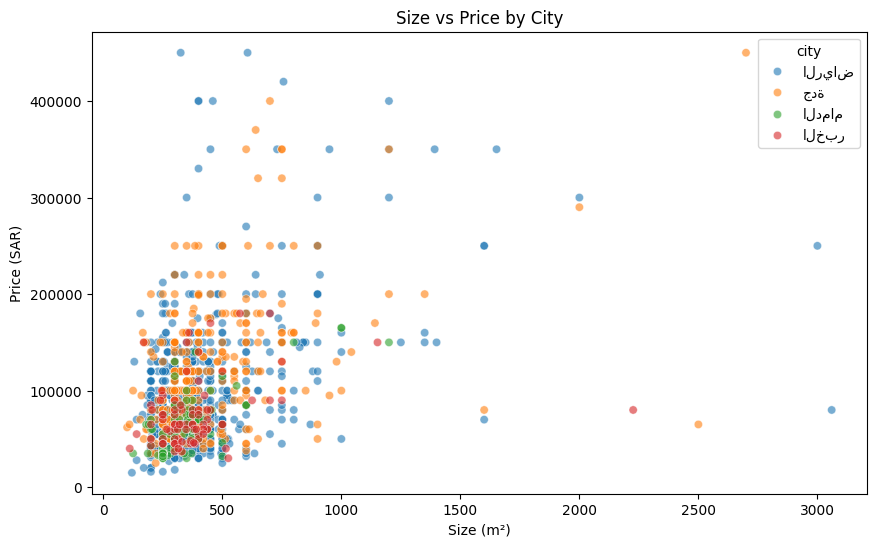

In [108]:
sns.scatterplot(data=df_clean, x="size", y="price", hue="city", alpha=0.6)
plt.title("Size vs Price by City")
plt.xlabel("Size (m²)")
plt.ylabel("Price (SAR)")
plt.show()

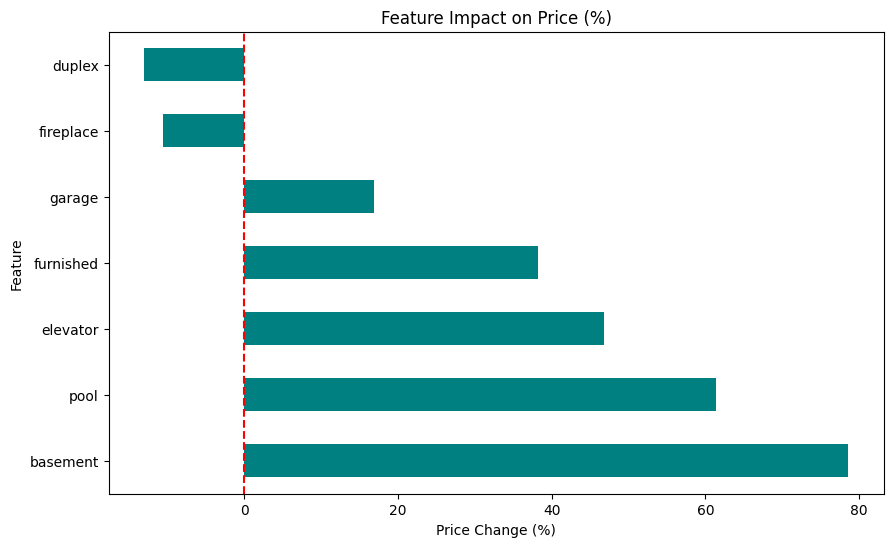

In [109]:
features = ["pool", "garage", "elevator", "fireplace", "basement", "duplex", "furnished"]

results = {}
for f in features:
    with_f = df_clean[df_clean[f] == 1]["price"].mean()
    without_f = df_clean[df_clean[f] == 0]["price"].mean()
    results[f] = ((with_f - without_f) / without_f) * 100

impact = pd.Series(results).sort_values(ascending=False)

impact.plot(kind="barh", color="teal")
plt.title("Feature Impact on Price (%)")
plt.xlabel("Price Change (%)")
plt.ylabel("Feature")
plt.axvline(x=0, color="red", linestyle="--")  
plt.show()

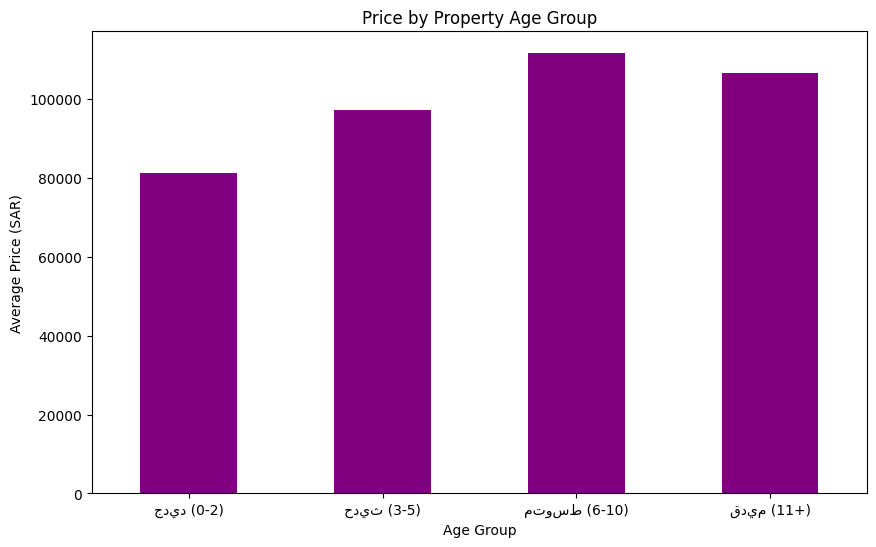

In [110]:
age_avg = df_clean.groupby("age_group")["price"].mean()

age_avg.plot(kind="bar", color="purple")
plt.title("Price by Property Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Price (SAR)")
plt.xticks(rotation=0)
plt.show()

In [111]:
df_clean.to_csv("data/SA_Aqar_final.csv", index=False)
print("✅ تم الحفظ!")
print(f"📊 الصفوف: {len(df_clean):,}")
print(f"📋 الأعمدة: {len(df_clean.columns)}")

✅ تم الحفظ!
📊 الصفوف: 1,480
📋 الأعمدة: 26


## 🎯 Key Findings & Insights

### 💰 Pricing by City
- **Jeddah** is the most expensive city (avg. 113,778 SAR)
- **Dammam** is the most affordable (avg. 61,647 SAR)
- Jeddah has the highest **price per square meter** (293 SAR/m²)

### 🏘️ Top Districts
- Most expensive district: **Hai Hateen** (Riyadh) - 256,667 SAR
- Most affordable districts are in Riyadh's outskirts (Al-Hair, Manfouha)
- **16x price gap** between the most and least expensive districts

### 🔍 Surprising Discoveries
1. **Bedrooms don't affect price** (correlation: 0.01) - unexpected!
2. **Living rooms matter more** than bedrooms (0.32 vs 0.01) - reflects Saudi culture
3. **6-10 year old properties are the most expensive** - not new ones!

### 🏠 Feature Impact on Price
| Feature | Price Impact |
|---------|-------------|
| Basement | +78.6% |
| Pool | +61.4% |
| Elevator | +46.8% |
| Fireplace | -10.6% ⚠️ |
| Duplex | -13.1% ⚠️ |

**Key Insight:** Rarer features (basement, pool) increase price more than common ones (garage).

## 💡 Recommendations

### For Buyers
- Best value for money: **Dammam** (larger properties, lower prices)
- For investment: **Jeddah** (highest price per m²)

### For Investors
- Properties aged **6-10 years** in established neighborhoods offer the best returns
- Adding a **basement or pool** significantly increases property value

## 📌 Conclusion
This analysis of 1,480 Saudi properties reveals that **location and rare amenities** drive prices more than the number of bedrooms. These insights can guide both buyers and investors in making data-driven decisions.